In [2]:
#loading dfs
import os
import pandas as pd
from pathlib import Path
p2 = Path("..") / "1_Source_Files" / "df_final_web_data_pt_1.txt"
df2 = pd.read_csv(p2, sep=",", encoding="utf-8", engine="python") 

p3 = Path("..") / "1_Source_Files" / "df_final_web_data_pt_2.txt"
df3 = pd.read_csv(p3, sep=",", encoding="utf-8", engine="python") 

pC = Path("..") / "1.1_Clean_Files" / "df_final_experiment_clients_clean.csv"
dfC = pd.read_csv(pC, sep=",", encoding="utf-8", engine="python") 

pD = Path("..") / "1.1_Clean_Files" / "df1_demo_clean.csv"
dfD = pd.read_csv(pD, sep=",", encoding="utf-8", engine="python") 

In [3]:
#visual check 1.1_Clean_Files\df_final_experiment_clients_clean.csv
df2.head()

,client_id,visitor_id,visit_id,process_step,date_time
0,9988021,580560515_7732621733,781255054_21935453173_531117,step_3,2017-04-17 15:27:07
1,9988021,580560515_7732621733,781255054_21935453173_531117,step_2,2017-04-17 15:26:51
2,9988021,580560515_7732621733,781255054_21935453173_531117,step_3,2017-04-17 15:19:22
3,9988021,580560515_7732621733,781255054_21935453173_531117,step_2,2017-04-17 15:19:13
4,9988021,580560515_7732621733,781255054_21935453173_531117,step_3,2017-04-17 15:18:04


In [4]:
#visual check
df3.head()

,client_id,visitor_id,visit_id,process_step,date_time
0,763412,601952081_10457207388,397475557_40440946728_419634,confirm,2017-06-06 08:56:00
1,6019349,442094451_91531546617,154620534_35331068705_522317,confirm,2017-06-01 11:59:27
2,6019349,442094451_91531546617,154620534_35331068705_522317,step_3,2017-06-01 11:58:48
3,6019349,442094451_91531546617,154620534_35331068705_522317,step_2,2017-06-01 11:58:08
4,6019349,442094451_91531546617,154620534_35331068705_522317,step_1,2017-06-01 11:57:58


In [5]:
#merging vertically dfs into df4
df4 = pd.concat([df2, df3], ignore_index=True)
df4 = df4.drop_duplicates()
df4.head()

,client_id,visitor_id,visit_id,process_step,date_time
0,9988021,580560515_7732621733,781255054_21935453173_531117,step_3,2017-04-17 15:27:07
1,9988021,580560515_7732621733,781255054_21935453173_531117,step_2,2017-04-17 15:26:51
2,9988021,580560515_7732621733,781255054_21935453173_531117,step_3,2017-04-17 15:19:22
3,9988021,580560515_7732621733,781255054_21935453173_531117,step_2,2017-04-17 15:19:13
4,9988021,580560515_7732621733,781255054_21935453173_531117,step_3,2017-04-17 15:18:04


In [6]:
#visual check 
df4.info()

<class 'pandas.DataFrame'>
Index: 744641 entries, 0 to 755404
Data columns (total 5 columns):
 #   Column        Non-Null Count   Dtype
---  ------        --------------   -----
 0   client_id     744641 non-null  int64
 1   visitor_id    744641 non-null  str  
 2   visit_id      744641 non-null  str  
 3   process_step  744641 non-null  str  
 4   date_time     744641 non-null  str  
dtypes: int64(1), str(4)
memory usage: 34.1 MB


In [7]:
#visual check
df4.isnull()

,client_id,visitor_id,visit_id,process_step,date_time
0,False,False,False,False,False
1,False,False,False,False,False
2,False,False,False,False,False
3,False,False,False,False,False
4,False,False,False,False,False
...,...,...,...,...,...
755400,False,False,False,False,False
755401,False,False,False,False,False
755402,False,False,False,False,False
755403,False,False,False,False,False


In [30]:
#cleaning and norilizing data
df4['client_id'] = df4['client_id'].astype(str).str.strip()
dfD['client_id'] = df4['client_id'].astype(str).str.strip()
df4['date_time'] = pd.to_datetime(df4['date_time'], errors='coerce')  

In [9]:
#cleaning and norilizing data
for text in ['visitor_id', 'visit_id', 'process_step']:
    if text in df4.columns:
        df4[text] = df4[text].astype(str).str.strip()

In [10]:
output_path = "../1.1_Clean_Files/df4_final_web_data_clean.csv"

df4.to_csv(output_path, index=False)


In [11]:
#visual check
df4 = df4.dropna(subset=['client_id', 'date_time'], how='any')

In [12]:
#visual check
print(df4.head())
print('rows:', len(df4))

  client_id            visitor_id                      visit_id process_step  \
0   9988021  580560515_7732621733  781255054_21935453173_531117       step_3   
1   9988021  580560515_7732621733  781255054_21935453173_531117       step_2   
2   9988021  580560515_7732621733  781255054_21935453173_531117       step_3   
3   9988021  580560515_7732621733  781255054_21935453173_531117       step_2   
4   9988021  580560515_7732621733  781255054_21935453173_531117       step_3   

            date_time  
0 2017-04-17 15:27:07  
1 2017-04-17 15:26:51  
2 2017-04-17 15:19:22  
3 2017-04-17 15:19:13  
4 2017-04-17 15:18:04  
rows: 744641


In [13]:
#visual check for understanding
id_val = 9988021
date_val = "2017-04-17" 
id_s = str(id_val)
target = pd.to_datetime(date_val).date()
result = df4[(df4['client_id'] == id_s) & (df4['date_time'].dt.date == target)]
print(result)

  client_id            visitor_id                      visit_id process_step  \
0   9988021  580560515_7732621733  781255054_21935453173_531117       step_3   
1   9988021  580560515_7732621733  781255054_21935453173_531117       step_2   
2   9988021  580560515_7732621733  781255054_21935453173_531117       step_3   
3   9988021  580560515_7732621733  781255054_21935453173_531117       step_2   
4   9988021  580560515_7732621733  781255054_21935453173_531117       step_3   
5   9988021  580560515_7732621733  781255054_21935453173_531117       step_2   
6   9988021  580560515_7732621733  781255054_21935453173_531117       step_1   
7   9988021  580560515_7732621733  781255054_21935453173_531117        start   

            date_time  
0 2017-04-17 15:27:07  
1 2017-04-17 15:26:51  
2 2017-04-17 15:19:22  
3 2017-04-17 15:19:13  
4 2017-04-17 15:18:04  
5 2017-04-17 15:17:15  
6 2017-04-17 15:17:01  
7 2017-04-17 15:16:22  


In [14]:
#visual check for understanding
id_val = 763412
#id_val = 6019349
date_val = "2017-06-06" 
id_s = str(id_val)
target = pd.to_datetime(date_val).date()
result = df4[df4['client_id'] == id_s]
display(result)

,client_id,visitor_id,visit_id,process_step,date_time
343141,763412,601952081_10457207388,397475557_40440946728_419634,confirm,2017-06-06 08:56:00
343322,763412,601952081_10457207388,275115855_33219234532_879732,confirm,2017-06-02 09:37:04
343323,763412,601952081_10457207388,275115855_33219234532_879732,step_3,2017-06-02 09:35:50
343324,763412,601952081_10457207388,275115855_33219234532_879732,step_2,2017-06-02 09:35:13
343325,763412,601952081_10457207388,275115855_33219234532_879732,step_1,2017-06-02 09:34:41
343326,763412,601952081_10457207388,275115855_33219234532_879732,start,2017-06-02 09:33:47


In [15]:
#visual check for understanding
id_val = 9988021
date_val = "2017-04-17" 
id_s = str(id_val)
target = pd.to_datetime(date_val).date()
result2 = df4[df4['process_step'] == "confirm" ]
display(result2)

,client_id,visitor_id,visit_id,process_step,date_time
8,8320017,39393514_33118319366,960651974_70596002104_312201,confirm,2017-04-05 13:10:05
13,4033851,762728880_76361333336,949661017_22392791362_127391,confirm,2017-04-05 12:29:03
14,4033851,762728880_76361333336,949661017_22392791362_127391,confirm,2017-04-05 12:29:01
15,4033851,762728880_76361333336,949661017_22392791362_127391,confirm,2017-04-05 12:28:52
24,1982004,618934751_10082078917,132494692_73738638511_70823,confirm,2017-04-17 12:02:42
...,...,...,...,...,...
755362,1462269,756274405_34153014475,903240226_7790404978_158729,confirm,2017-06-03 11:49:32
755368,9563467,358754208_29929976792,898272434_72817818195_285148,confirm,2017-06-04 10:21:23
755375,2443347,818414719_69544570654,148166449_67114410166_524360,confirm,2017-05-30 19:18:18
755376,9895983,473024645_56027518531,498981662_93503779869_272484,confirm,2017-06-15 19:55:09


In [16]:

dfC.head()

,client_id,Variation
0,9988021,Test
1,8320017,Test
2,4033851,Control
3,1982004,Test
4,9294070,Control


In [17]:
client_id = 9988021
id_s = str(client_id)
target = pd.to_datetime(date_val).date()
result = dfC[dfC['client_id'] == id_s]
display(result)

,client_id,Variation


In [18]:
dfC['client_id'] = dfC['client_id'].astype(str)
df4C = df4.merge(dfC[['client_id','Variation']], on='client_id', how='left')

In [19]:
#visual check for understanding
id_val = 763412
#id_val = 6019349
date_val = "2017-06-06" 
id_s = str(id_val)
target = pd.to_datetime(date_val).date()
result = df4C[df4C['client_id'] == id_s]
display(result)

,client_id,visitor_id,visit_id,process_step,date_time,Variation
341046,763412,601952081_10457207388,397475557_40440946728_419634,confirm,2017-06-06 08:56:00,NaN
341225,763412,601952081_10457207388,275115855_33219234532_879732,confirm,2017-06-02 09:37:04,NaN
341226,763412,601952081_10457207388,275115855_33219234532_879732,step_3,2017-06-02 09:35:50,NaN
341227,763412,601952081_10457207388,275115855_33219234532_879732,step_2,2017-06-02 09:35:13,NaN
341228,763412,601952081_10457207388,275115855_33219234532_879732,step_1,2017-06-02 09:34:41,NaN
341229,763412,601952081_10457207388,275115855_33219234532_879732,start,2017-06-02 09:33:47,NaN


In [20]:

dfC_agg = dfC.sort_values('client_id').groupby('client_id', as_index=False)['Variation'].first()

df4_with_variation = df4.merge(dfC_agg, on='client_id', how='inner')

# report counts
print("original df4 rows:", len(df4))
print("rows with assigned variation:", len(df4_with_variation))


original df4 rows: 744641
rows with assigned variation: 443897


In [21]:
output_path = "../1.1_Clean_Files/final_web_data_plus_experiments_clients.csv"

df4_with_variation.to_csv(output_path, index=False)


In [22]:
df5 = df4_with_variation

In [23]:
df5.info()

<class 'pandas.DataFrame'>
RangeIndex: 443897 entries, 0 to 443896
Data columns (total 6 columns):
 #   Column        Non-Null Count   Dtype         
---  ------        --------------   -----         
 0   client_id     443897 non-null  str           
 1   visitor_id    443897 non-null  str           
 2   visit_id      443897 non-null  str           
 3   process_step  443897 non-null  str           
 4   date_time     443897 non-null  datetime64[us]
 5   Variation     443897 non-null  str           
dtypes: datetime64[us](1), str(5)
memory usage: 20.3 MB


In [24]:
df5.Variation.unique()

<StringArray>
['Test', 'Control', 'empty']
Length: 3, dtype: str

In [25]:
dfC.Variation.unique()

<StringArray>
['Test', 'Control', 'empty']
Length: 3, dtype: str

In [26]:
df5[df5['Variation'] == 'Test']

,client_id,visitor_id,visit_id,process_step,date_time,Variation
0,9988021,580560515_7732621733,781255054_21935453173_531117,step_3,2017-04-17 15:27:07,Test
1,9988021,580560515_7732621733,781255054_21935453173_531117,step_2,2017-04-17 15:26:51,Test
2,9988021,580560515_7732621733,781255054_21935453173_531117,step_3,2017-04-17 15:19:22,Test
3,9988021,580560515_7732621733,781255054_21935453173_531117,step_2,2017-04-17 15:19:13,Test
4,9988021,580560515_7732621733,781255054_21935453173_531117,step_3,2017-04-17 15:18:04,Test
...,...,...,...,...,...,...
413009,1574008,117364417_77840596075,528720790_71583064618_169151,confirm,2017-05-06 23:51:05,Test
413010,1574008,117364417_77840596075,528720790_71583064618_169151,step_3,2017-05-06 23:50:40,Test
413011,1574008,117364417_77840596075,528720790_71583064618_169151,step_2,2017-05-06 23:43:47,Test
413012,1574008,117364417_77840596075,528720790_71583064618_169151,step_1,2017-05-06 23:43:34,Test


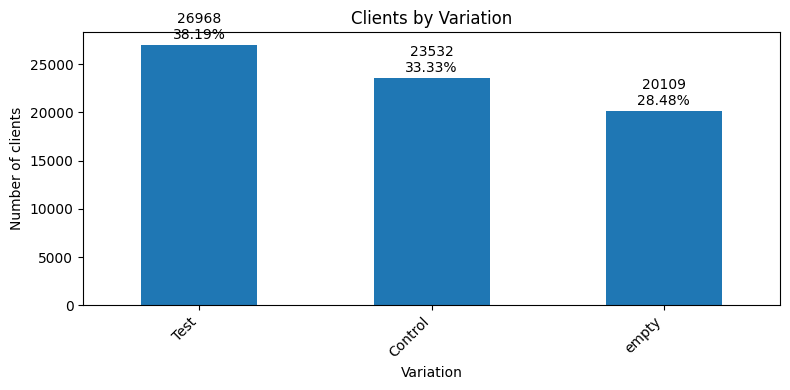

In [35]:
import matplotlib.pyplot as plt

# counts of unique clients by Variation
counts = df5.drop_duplicates('client_id')['Variation'].value_counts(dropna=False)

fig, ax = plt.subplots(figsize=(8,4))
counts.plot(kind='bar', color='C0', ax=ax)

total = counts.sum()
for x, v in enumerate(counts):
    ax.text(x, v + total*0.005, f"{v}\n{v/total*100:.2f}%", ha='center', va='bottom')

ax.set_xlabel('Variation')
ax.set_ylabel('Number of clients')
ax.set_title('Clients by Variation')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()


In [36]:
df5.client_id.unique()

<StringArray>
['9988021', '8320017', '4033851', '1982004', '9294070', '9466803', '3170143',
 '6651403', '5887227', '2105948',
 ...
 '7598995',  '988886', '8973570', '9979751',  '104557', '4899619', '1672289',
 '1020453', '3897324', '9895983']
Length: 70609, dtype: str

In [31]:

dfC_agg = dfC.sort_values('client_id').groupby('client_id', as_index=False)['Variation'].first()

dfD_with_variation = dfD.merge(dfC_agg, on='client_id', how='inner')

# report counts
print("original df4 rows:", len(dfD))
print("rows with assigned variation:", len(dfD_with_variation))

original df4 rows: 70595
rows with assigned variation: 69049


In [32]:
df6=dfD_with_variation

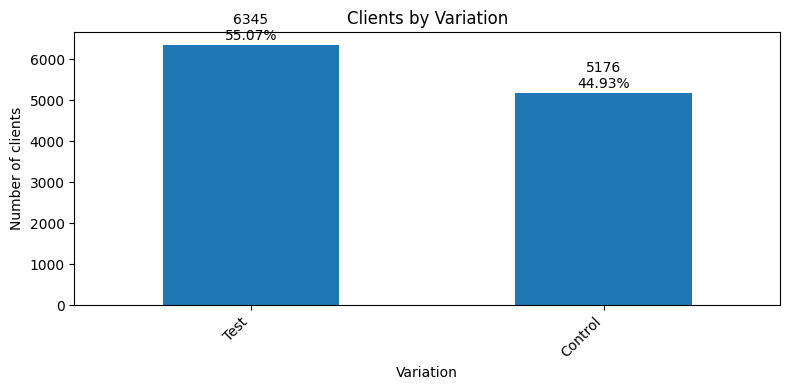

In [33]:
import matplotlib.pyplot as plt

# counts of unique clients by Variation
counts = df6.drop_duplicates('client_id')['Variation'].value_counts(dropna=False)

fig, ax = plt.subplots(figsize=(8,4))
counts.plot(kind='bar', color='C0', ax=ax)

total = counts.sum()
for x, v in enumerate(counts):
    ax.text(x, v + total*0.005, f"{v}\n{v/total*100:.2f}%", ha='center', va='bottom')

ax.set_xlabel('Variation')
ax.set_ylabel('Number of clients')
ax.set_title('Clients by Variation')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [37]:
df6.client_id.unique()

<StringArray>
['9988021', '8320017', '4033851', '1982004', '9294070', '9466803', '3170143',
 '6651403', '5887227', '2105948',
 ...
 '1273208', '5128721', '4358186', '2547675', '8079923', '9888495', '8914780',
 '6137908',  '292583', '6829681']
Length: 11521, dtype: str

In [38]:
dfC.client_id.unique()

<StringArray>
['9988021', '8320017', '4033851', '1982004', '9294070', '9466803', '3170143',
 '6651403', '5887227', '2105948',
 ...
 '5217934', '1020453', '9722009', '3897324',  '687702', '2443347', '8788427',
  '266828', '1266421', '9895983']
Length: 70609, dtype: str

In [39]:
output_path = "../1.1_Clean_Files/df1_demo_clean_plus_experiments_clients.csv"

df6.to_csv(output_path, index=False)